# Parcial 01: Regresion Logistica, Red Neuronal y PCA

**Estudiante:** Eriksson Hernandez  
**Dataset:** `breast-cancer.csv`  
**Tema:** Regresion lineal, Red Neuronal y PCA aplicados a un dataset de cancer de mama.

El objetivo es clasificar el diagnostico del tumor como benigno (`B`) o maligno (`M`) mediante regresion logistica y una red neuronal simple, comparando el desempeno con variables originales y con componentes principales.

## 1. Carga de librerias

In [1]:
import os
from pathlib import Path

os.environ["MPLCONFIGDIR"] = "/tmp/mplconfig"

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

## 2. Parametros del ejercicio

In [ ]:
DATA_PATH = Path("../data/breast-cancer.csv")

# Set first 4 digits of the student ID as random seed for reproducibility
LAST_4_DIGITS = 2927
TRAIN_SIZE = 0.70
TARGET_COLUMN = "diagnosis"
ID_COLUMN = "id"

## 3. Carga y exploracion inicial

La variable objetivo `diagnosis` contiene dos clases: `B` para tumores benignos y `M` para tumores malignos.

In [3]:
datos = pd.read_csv(DATA_PATH)

print(f"Filas: {datos.shape[0]}")
print(f"Columnas: {datos.shape[1]}")
datos.head()

Filas: 569
Columnas: 32


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [5]:
print("Valores faltantes por columna:")
display(datos.isna().sum().to_frame("faltantes").T)

print("\nDistribucion de la variable objetivo:")
display(datos[TARGET_COLUMN].value_counts().to_frame("conteo"))

Valores faltantes por columna:


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
faltantes,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Distribucion de la variable objetivo:


,conteo
diagnosis,
B,357
M,212


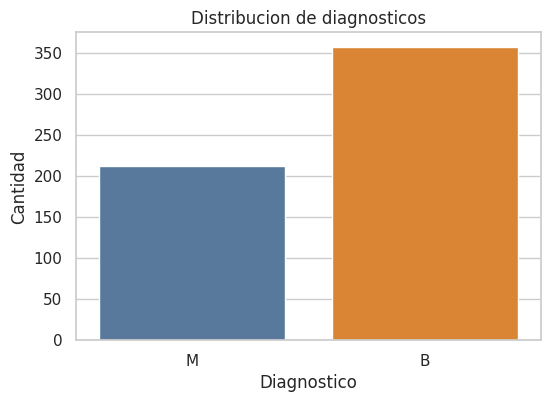

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=datos, x=TARGET_COLUMN, hue=TARGET_COLUMN, palette=["#4C78A8", "#F58518"], legend=False)
plt.title("Distribucion de diagnosticos")
plt.xlabel("Diagnostico")
plt.ylabel("Cantidad")
plt.show()

In [7]:
variables_numericas = datos.drop(columns=[ID_COLUMN, TARGET_COLUMN]).columns
datos[variables_numericas].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
texture_mean,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
area_mean,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
compactness_mean,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
concavity_mean,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
concave points_mean,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


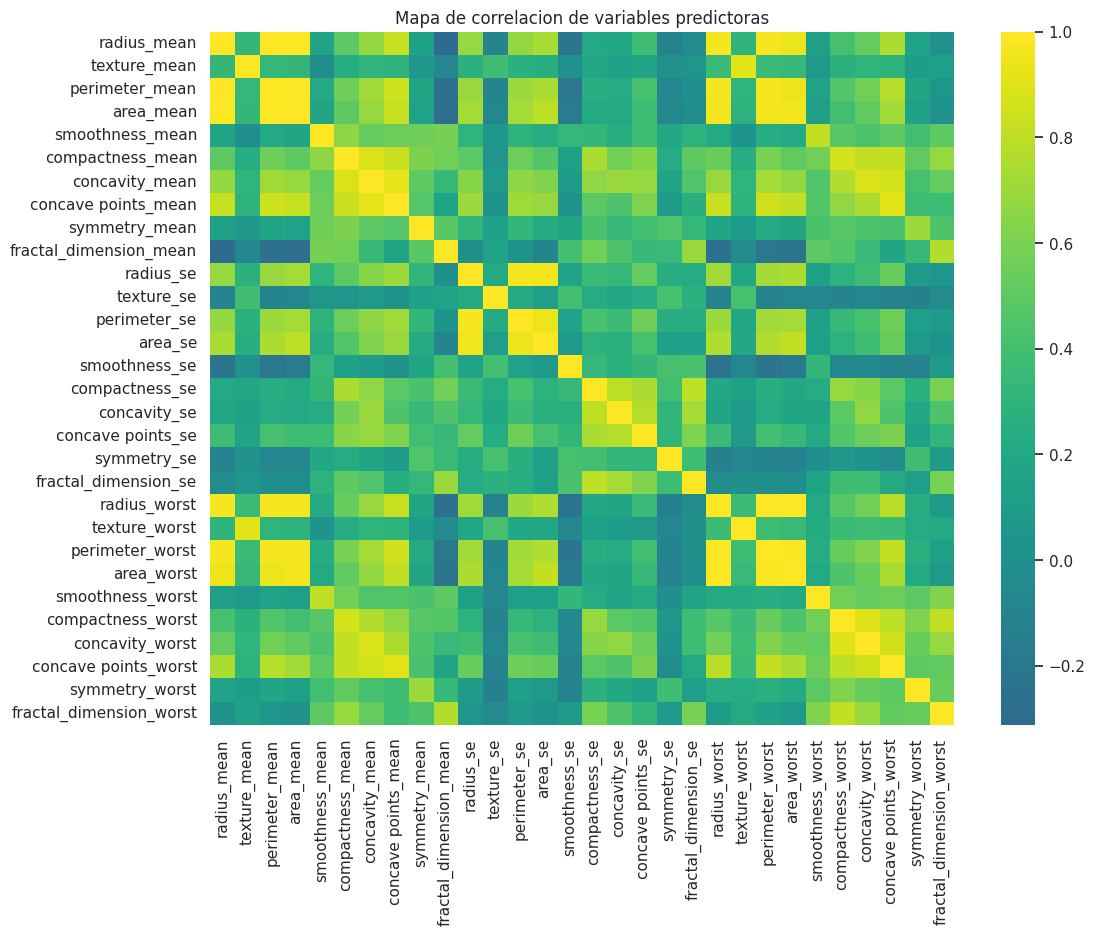

In [8]:
plt.figure(figsize=(12, 9))
corr = datos[variables_numericas].corr()
sns.heatmap(corr, cmap="viridis", center=0)
plt.title("Mapa de correlacion de variables predictoras")
plt.show()

## 4. Preparacion de datos

Se elimina la columna `id` porque es un identificador y no una caracteristica predictiva. La variable objetivo se codifica como:

- `B` = 0
- `M` = 1

La separacion de entrenamiento y prueba se realiza de forma aleatoria con `random_state = 2927` y proporcion 70%/30%. Se usa estratificacion para conservar proporciones similares de clases en ambos conjuntos.

In [9]:
X = datos.drop(columns=[ID_COLUMN, TARGET_COLUMN])
y = datos[TARGET_COLUMN].map({"B": 0, "M": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=TRAIN_SIZE,
    random_state=LAST_4_DIGITS,
    shuffle=True,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("\nDistribucion en entrenamiento:")
display(y_train.value_counts().rename(index={0: "B", 1: "M"}).to_frame("conteo"))
print("\nDistribucion en prueba:")
display(y_test.value_counts().rename(index={0: "B", 1: "M"}).to_frame("conteo"))

X_train: (398, 30)
X_test: (171, 30)

Distribucion en entrenamiento:


,conteo
diagnosis,
B,250
M,148



Distribucion en prueba:


,conteo
diagnosis,
B,107
M,64


## 5. Normalizacion

Aunque se entrenan modelos con las variables originales, estas se estandarizan antes del entrenamiento. Esto mantiene las variables originales, pero evita que las diferencias de escala afecten la regresion logistica, la red neuronal y el PCA.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

## 6. Modelos con variables originales

In [11]:
def evaluar_modelo(nombre, modelo, X_entrenamiento, X_prueba, y_entrenamiento, y_prueba):
    modelo.fit(X_entrenamiento, y_entrenamiento)

    pred_train = modelo.predict(X_entrenamiento)
    pred_test = modelo.predict(X_prueba)

    return {
        "Modelo": nombre,
        "Accuracy entrenamiento": accuracy_score(y_entrenamiento, pred_train),
        "Accuracy prueba": accuracy_score(y_prueba, pred_test),
        "Predicciones prueba": pred_test,
        "Modelo entrenado": modelo,
    }


modelo_lr_original = LogisticRegression(max_iter=5000, random_state=LAST_4_DIGITS)

modelo_nn_original = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,
    max_iter=1500,
    random_state=LAST_4_DIGITS,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
)

resultados_originales = [
    evaluar_modelo(
        "Regresion Logistica - Original",
        modelo_lr_original,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
    ),
    evaluar_modelo(
        "Red Neuronal - Original",
        modelo_nn_original,
        X_train_scaled,
        X_test_scaled,
        y_train,
        y_test,
    ),
]

pd.DataFrame([
    {k: v for k, v in resultado.items() if k not in ["Predicciones prueba", "Modelo entrenado"]}
    for resultado in resultados_originales
])

,Modelo,Accuracy entrenamiento,Accuracy prueba
0,Regresion Logistica - Original,0.989950,0.976608
1,Red Neuronal - Original,0.922111,0.906433


In [12]:
for resultado in resultados_originales:
    print(resultado["Modelo"])
    print(confusion_matrix(y_test, resultado["Predicciones prueba"]))
    print(classification_report(y_test, resultado["Predicciones prueba"], target_names=["Benigno", "Maligno"]))
    print("-" * 70)

Regresion Logistica - Original
[[107   0]
 [  4  60]]
              precision    recall  f1-score   support

     Benigno       0.96      1.00      0.98       107
     Maligno       1.00      0.94      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171

----------------------------------------------------------------------
Red Neuronal - Original
[[104   3]
 [ 13  51]]
              precision    recall  f1-score   support

     Benigno       0.89      0.97      0.93       107
     Maligno       0.94      0.80      0.86        64

    accuracy                           0.91       171
   macro avg       0.92      0.88      0.90       171
weighted avg       0.91      0.91      0.90       171

----------------------------------------------------------------------


## 7. Analisis de componentes principales PCA

PCA se ajusta con los datos de entrenamiento estandarizados. El objetivo es identificar la cantidad de componentes principales necesarios para alcanzar al menos 80% de varianza explicada acumulada.

In [13]:
pca = PCA()
pca.fit(X_train_scaled)

tabla_pca = pd.DataFrame({
    "Componente": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza explicada": pca.explained_variance_ratio_,
    "Varianza acumulada": pca.explained_variance_ratio_.cumsum(),
})

n_componentes_80 = int(np.argmax(tabla_pca["Varianza acumulada"].values >= 0.80) + 1)
varianza_80 = tabla_pca.loc[n_componentes_80 - 1, "Varianza acumulada"]

print(f"Componentes necesarios para alcanzar al menos 80%: {n_componentes_80}")
print(f"Varianza acumulada alcanzada: {varianza_80:.4f} ({varianza_80:.2%})")

tabla_pca.head(10)

Componentes necesarios para alcanzar al menos 80%: 5
Varianza acumulada alcanzada: 0.8482 (84.82%)


,Componente,Varianza explicada,Varianza acumulada
0,1,0.438035,0.438035
1,2,0.192841,0.630876
2,3,0.095012,0.725888
3,4,0.064543,0.790431
4,5,0.057720,0.848150
5,6,0.040388,0.888538
6,7,0.020986,0.909525
7,8,0.015117,0.924642
8,9,0.014393,0.939035
9,10,0.012489,0.951525


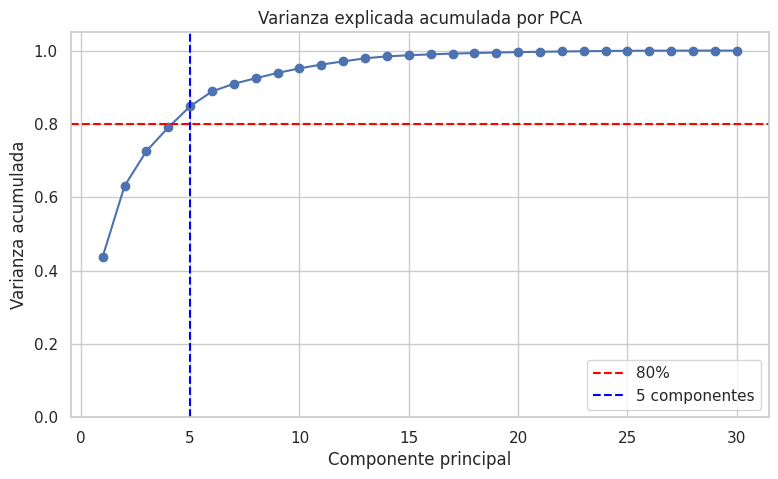

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tabla_pca["Componente"], tabla_pca["Varianza acumulada"], marker="o")
ax.axhline(0.80, color="red", linestyle="--", label="80%")
ax.axvline(n_componentes_80, color="blue", linestyle="--", label=f"{n_componentes_80} componentes")
ax.set_title("Varianza explicada acumulada por PCA")
ax.set_xlabel("Componente principal")
ax.set_ylabel("Varianza acumulada")
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

## 8. Transformacion PCA al 80%

In [15]:
pca_80 = PCA(n_components=n_componentes_80)
X_train_pca = pca_80.fit_transform(X_train_scaled)
X_test_pca = pca_80.transform(X_test_scaled)

columnas_pca = [f"PC{i}" for i in range(1, n_componentes_80 + 1)]
X_train_pca = pd.DataFrame(X_train_pca, columns=columnas_pca, index=X_train.index)
X_test_pca = pd.DataFrame(X_test_pca, columns=columnas_pca, index=X_test.index)

X_train_pca.head()

,PC1,PC2,PC3,PC4,PC5
160,-0.686889,1.745171,1.406348,0.093816,1.622790
499,5.013354,-2.062504,-0.755545,0.058640,-0.181403
513,-1.257896,-1.466872,-0.453259,-1.900890,-0.825934
49,-1.663101,-1.309268,-0.280213,1.691588,-0.119234
271,-3.294620,0.314368,-1.037575,-1.961129,-0.155506


## 9. Modelos con PCA

In [16]:
modelo_lr_pca = LogisticRegression(max_iter=5000, random_state=LAST_4_DIGITS)

modelo_nn_pca = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=0.001,
    max_iter=1500,
    random_state=LAST_4_DIGITS,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=30,
)

resultados_pca = [
    evaluar_modelo(
        "Regresion Logistica - PCA 80%",
        modelo_lr_pca,
        X_train_pca,
        X_test_pca,
        y_train,
        y_test,
    ),
    evaluar_modelo(
        "Red Neuronal - PCA 80%",
        modelo_nn_pca,
        X_train_pca,
        X_test_pca,
        y_train,
        y_test,
    ),
]

pd.DataFrame([
    {k: v for k, v in resultado.items() if k not in ["Predicciones prueba", "Modelo entrenado"]}
    for resultado in resultados_pca
])

,Modelo,Accuracy entrenamiento,Accuracy prueba
0,Regresion Logistica - PCA 80%,0.987437,0.959064
1,Red Neuronal - PCA 80%,0.979899,0.953216


In [17]:
for resultado in resultados_pca:
    print(resultado["Modelo"])
    print(confusion_matrix(y_test, resultado["Predicciones prueba"]))
    print(classification_report(y_test, resultado["Predicciones prueba"], target_names=["Benigno", "Maligno"]))
    print("-" * 70)

Regresion Logistica - PCA 80%
[[106   1]
 [  6  58]]
              precision    recall  f1-score   support

     Benigno       0.95      0.99      0.97       107
     Maligno       0.98      0.91      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171

----------------------------------------------------------------------
Red Neuronal - PCA 80%
[[104   3]
 [  5  59]]
              precision    recall  f1-score   support

     Benigno       0.95      0.97      0.96       107
     Maligno       0.95      0.92      0.94        64

    accuracy                           0.95       171
   macro avg       0.95      0.95      0.95       171
weighted avg       0.95      0.95      0.95       171

----------------------------------------------------------------------


## 10. Resumen comparativo de los 4 modelos

In [18]:
resumen = []

for resultado in resultados_originales:
    resumen.append({
        "Modelo": resultado["Modelo"],
        "Dataset": "Variables originales",
        "Variables/componentes": X_train_scaled.shape[1],
        "Accuracy entrenamiento": resultado["Accuracy entrenamiento"],
        "Accuracy prueba": resultado["Accuracy prueba"],
    })

for resultado in resultados_pca:
    resumen.append({
        "Modelo": resultado["Modelo"],
        "Dataset": f"PCA 80% ({varianza_80:.2%})",
        "Variables/componentes": n_componentes_80,
        "Accuracy entrenamiento": resultado["Accuracy entrenamiento"],
        "Accuracy prueba": resultado["Accuracy prueba"],
    })

tabla_resumen = pd.DataFrame(resumen)
tabla_resumen["Accuracy entrenamiento"] = tabla_resumen["Accuracy entrenamiento"].round(4)
tabla_resumen["Accuracy prueba"] = tabla_resumen["Accuracy prueba"].round(4)
tabla_resumen = tabla_resumen.sort_values("Accuracy prueba", ascending=False).reset_index(drop=True)
tabla_resumen

,Modelo,Dataset,Variables/componentes,Accuracy entrenamiento,Accuracy prueba
0,Regresion Logistica - Original,Variables originales,30,0.9899,0.9766
1,Regresion Logistica - PCA 80%,PCA 80% (84.82%),5,0.9874,0.9591
2,Red Neuronal - PCA 80%,PCA 80% (84.82%),5,0.9799,0.9532
3,Red Neuronal - Original,Variables originales,30,0.9221,0.9064


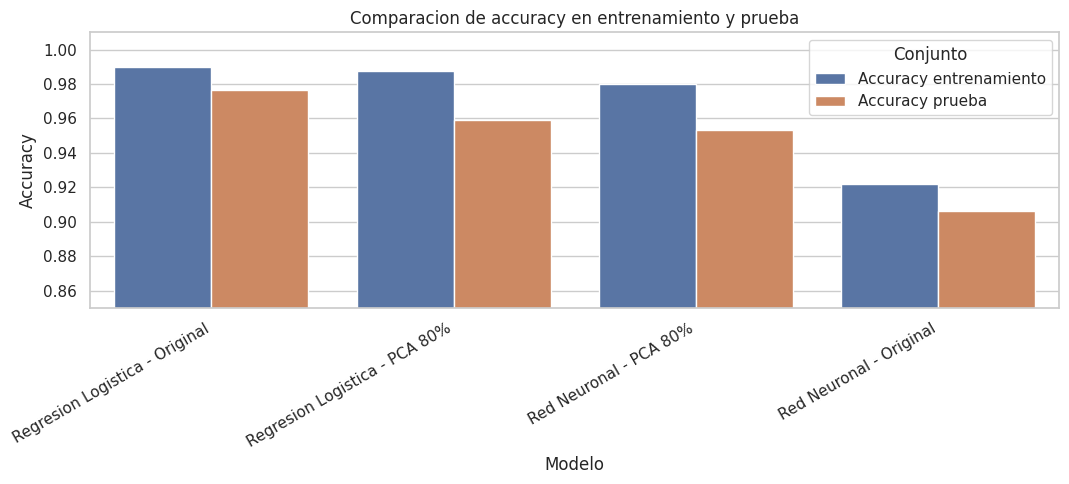

In [19]:
tabla_melt = tabla_resumen.melt(
    id_vars=["Modelo"],
    value_vars=["Accuracy entrenamiento", "Accuracy prueba"],
    var_name="Conjunto",
    value_name="Accuracy",
)

plt.figure(figsize=(11, 5))
sns.barplot(data=tabla_melt, x="Modelo", y="Accuracy", hue="Conjunto")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=30, ha="right")
plt.title("Comparacion de accuracy en entrenamiento y prueba")
plt.tight_layout()
plt.show()

## 11. Conclusiones

- El dataset contiene 569 observaciones y 30 variables predictoras numericas despues de excluir `id` y `diagnosis`. No se encontraron valores faltantes.
- La separacion se realizo con `random_state = 2927`, usando 70% de datos para entrenamiento y 30% para prueba.
- Con las variables originales, la regresion logistica obtuvo el mejor desempeno general: accuracy de entrenamiento de aproximadamente 0.9899 y accuracy de prueba de aproximadamente 0.9766.
- La red neuronal simple con tres capas ocultas obtuvo accuracy de prueba de aproximadamente 0.9064 con variables originales. En este caso, no supero a la regresion logistica.
- En el analisis PCA, se necesitaron 5 componentes principales para superar el 80% de varianza explicada acumulada. Estos 5 componentes explicaron aproximadamente 84.82% de la variabilidad de los datos de entrenamiento.
- Con PCA, la regresion logistica alcanzo accuracy de prueba de aproximadamente 0.9591 y la red neuronal alcanzo aproximadamente 0.9532. Ambos modelos redujeron la dimensionalidad de 30 variables a 5 componentes, manteniendo una precision alta.
- El mejor algoritmo en general fue la regresion logistica con variables originales, porque obtuvo la mayor precision en el conjunto de prueba. PCA fue util para simplificar el modelo y reducir dimensionalidad, aunque produjo una ligera disminucion en precision frente al modelo con variables originales.